# Visual Relationship Detection via Visual Phrases
**Paper:** *Recognizing Actions as the Meeting of Visual Phrases* — Sadeghi & Farhadi, CVPR 2011

**Core Idea:**  Instead of detecting subject + predicate + object separately, train a holistic DPM on the *tight bounding box of the whole phrase* (e.g. the box covering both person and bicycle in "person_riding_bicycle"). At inference combine three scoring strategies:
- **Ph**: phrase DPM score only
- **Obj**: individual object DPM scores only (sum)
- **Ph+Obj**: phrase + objects combined

**Dataset:** UIUC Phrasal Recognition Dataset — VOC3000 subset (~3000 images, 17+ visual phrases)

**DPM stand-in:** HOG features + LinearSVC with hard negative mining (mirrors voc-release5 training loop in Python)


In [1]:
import os
import glob
import random
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xml.etree.ElementTree as ET
import cv2

from ultralytics import YOLO
from skimage.feature import hog
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict, Counter

print('imports ok')

imports ok


In [2]:
# ---- paths ----
DATASET_ROOT = r'G:\Engineering\GP\Expirements\VRD\UIUC_PhrasalRecognitionDataset\VOC3000'
ANN_DIR  = os.path.join(DATASET_ROOT, 'Annotations')
IMG_DIR  = os.path.join(DATASET_ROOT, 'JPEGImages')

# ---- HOG params (voc-release5 spirit: 8x8 cells, 9 bins, L2-Hys norm) ----
HOG_PIX = (8, 8)
HOG_BLK = (2, 2)
HOG_ORI = 9

# ---- ASPECT-RATIO-AWARE detection windows (mirrors DPM mixture components) ----
# Squashing tall phrase boxes (median AR ~0.61) into a square distorts the HOG
# template AND a square sliding window caps IoU>=0.5 recall at ~74%.
# Matching the window aspect ratio to the phrase's median GT box lifts that
# ceiling to ~97%. So we derive a per-label window instead of one fixed size.
BASE_H = 128            # fixed window height; width follows the median aspect ratio
MIN_W, MAX_W = 56, 184  # clamp width so feature dim stays sane

WIN = {}   # label -> (H, W), populated during training

def compute_window(label, all_anns, base_h=BASE_H, min_w=MIN_W, max_w=MAX_W):
    """Window (H,W) whose aspect ratio = median GT aspect ratio of `label`."""
    ars = []
    for ann in all_anns:
        for o in ann['objects']:
            if o['name'] == label:
                x1, y1, x2, y2 = o['bbox']
                w, h = x2 - x1, y2 - y1
                if w > 4 and h > 4:
                    ars.append(w / h)
    ar = float(np.median(ars)) if ars else 1.0
    W  = int(round(base_h * ar / 8) * 8)        # keep width a multiple of cell size
    W  = int(np.clip(W, min_w, max_w))
    return (base_h, W)

# multi-scale pyramid (GT boxes range ~130px .. ~800px in ~600x480 images)
PH_SCALES  = [1.0, 0.75, 0.55, 0.40, 0.30]
OBJ_SCALES = [1.0, 0.75, 0.55, 0.40]

SVM_C    = 0.01    # was 0.001 (over-regularized for high-dim HOG)
USE_FLIP = True    # horizontal-flip augmentation for positives (doubles training data)

random.seed(42)
np.random.seed(42)
print('config ready')

config ready


In [3]:
# ---- YOLO object detector (replaces HOG+SVM per-class models) ----
YOLO_MODEL = YOLO('yolov8s.pt')   # yolov8s balances speed vs accuracy; swap for yolov8m/l for higher AP

# UIUC dataset names → COCO names (YOLO is trained on COCO)
DATASET_TO_COCO = {
    'aeroplane': 'airplane',
    'bicycle':   'bicycle',
    'bird':      'bird',
    'bottle':    'bottle',
    'car':       'car',
    'cat':       'cat',
    'chair':     'chair',
    'dog':       'dog',
    'horse':     'horse',
    'person':    'person',
    'sofa':      'couch',
}
COCO_TO_DATASET = {v: k for k, v in DATASET_TO_COCO.items()}
print('YOLO model ready:', YOLO_MODEL.info())

YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs
YOLO model ready: (129, 11166560, 0, 28.816844800000002)


## 1. Parse annotations

In [4]:
def parse_xml(xml_path):
    root = ET.parse(xml_path).getroot()
    filename = root.find('filename').text
    sz = root.find('size')
    W = int(sz.find('width').text)
    H = int(sz.find('height').text)
    objs = []
    for o in root.findall('object'):
        bb = o.find('bndbox')
        objs.append({
            'name': o.find('name').text,
            'bbox': [
                int(float(bb.find('xmin').text)),
                int(float(bb.find('ymin').text)),
                int(float(bb.find('xmax').text)),
                int(float(bb.find('ymax').text)),
            ]
        })
    return {'filename': filename, 'W': W, 'H': H, 'objects': objs}


xml_files = sorted(glob.glob(os.path.join(ANN_DIR, '*.xml')))
all_anns  = [parse_xml(xf) for xf in xml_files]
print(f'total images: {len(all_anns)}')

total images: 2978


## 2. Explore the dataset

In [5]:
all_names = [o['name'] for ann in all_anns for o in ann['objects']]
name_cnt  = Counter(all_names)

# split into visual phrases vs individual objects vs negatives
PHRASES = sorted([n for n in name_cnt if '_' in n and n != 'absolute_negatives'])
OBJ_CLS = sorted([n for n in name_cnt if '_' not in n])
NEGS    = ['absolute_negatives']

print(f'Visual phrases ({len(PHRASES)}):')
for p in PHRASES:
    print(f'  {p}: {name_cnt[p]}')

print(f'\nIndividual objects: {OBJ_CLS}')

Visual phrases (21):
  aeroplane_flying_in_sky: 85
  aeroplane_parked_at_airport: 101
  bicycle_nextto_car: 88
  bird_flying_in_sky: 133
  cat_lying_on_sofa: 114
  dog_jumping: 85
  dog_lying_on_sofa: 123
  dog_running: 213
  person_drinking_bottle: 93
  person_jumping: 79
  person_jumping_on_horse: 117
  person_lying_in_beach: 123
  person_lying_on_sofa: 63
  person_nextto_bicycle: 104
  person_nextto_car: 95
  person_nextto_horse: 82
  person_riding_bicycle: 180
  person_riding_horse: 503
  person_running: 145
  person_sitting_on_chair: 162
  person_sitting_on_sofa: 168

Individual objects: ['aeroplane', 'bicycle', 'bird', 'bottle', 'car', 'cat', 'chair', 'dog', 'horse', 'person', 'sofa']


In [6]:
# images per phrase
phrase_to_anns = defaultdict(list)
for ann in all_anns:
    seen = set()
    for o in ann['objects']:
        if o['name'] in PHRASES and o['name'] not in seen:
            phrase_to_anns[o['name']].append(ann)
            seen.add(o['name'])

print('images per phrase:')
for ph, lst in sorted(phrase_to_anns.items(), key=lambda x: -len(x[1])):
    print(f'  {ph}: {len(lst)}')

images per phrase:
  person_riding_horse: 314
  dog_running: 145
  person_sitting_on_chair: 120
  person_jumping_on_horse: 117
  person_riding_bicycle: 116
  person_sitting_on_sofa: 109
  dog_lying_on_sofa: 98
  person_nextto_car: 90
  bicycle_nextto_car: 87
  cat_lying_on_sofa: 86
  person_nextto_bicycle: 86
  person_running: 84
  bird_flying_in_sky: 82
  dog_jumping: 81
  person_lying_in_beach: 78
  aeroplane_parked_at_airport: 77
  person_drinking_bottle: 77
  aeroplane_flying_in_sky: 76
  person_nextto_horse: 76
  person_jumping: 62
  person_lying_on_sofa: 56


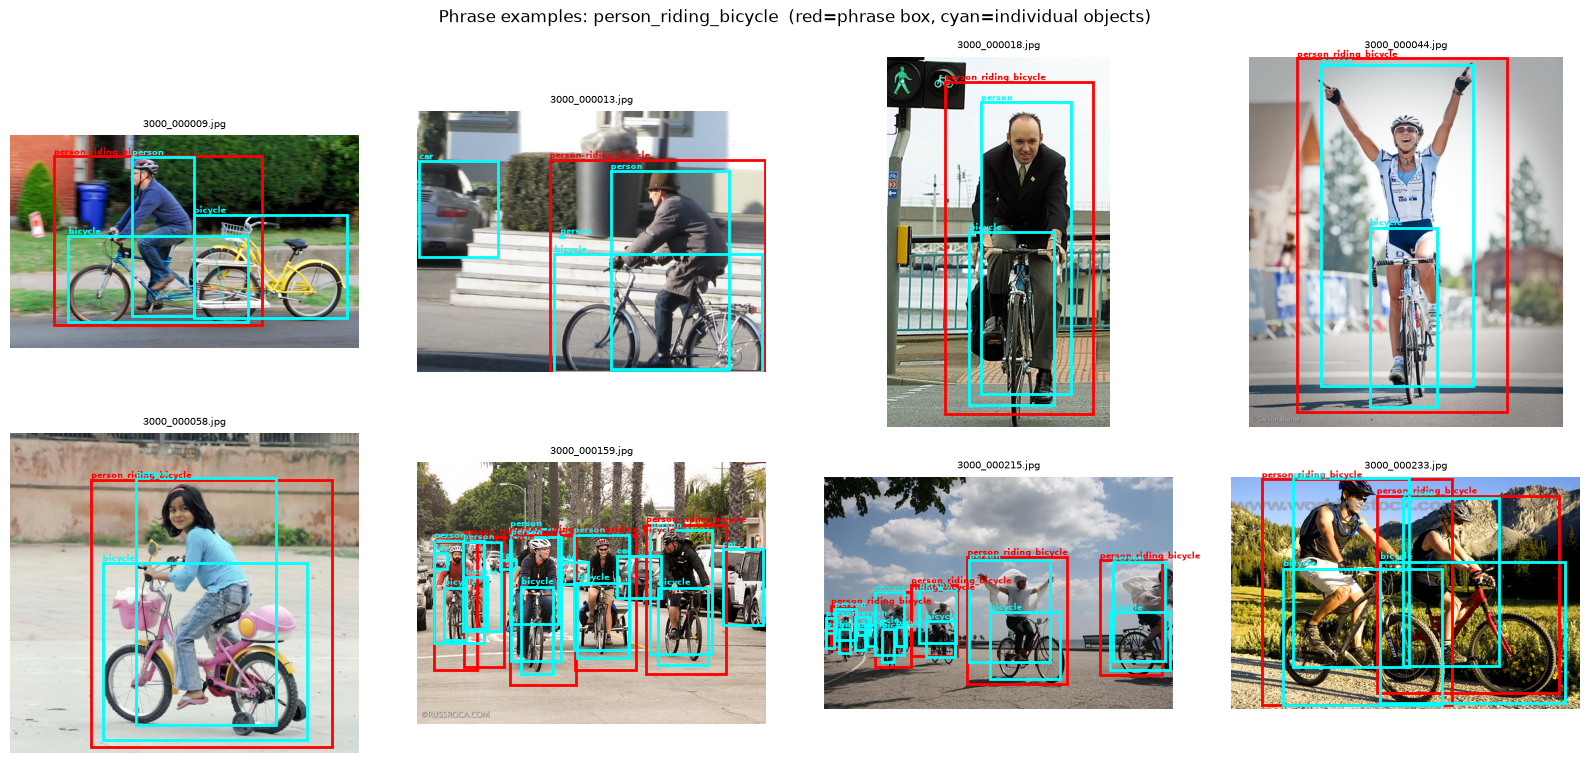

In [7]:
# pick a phrase to work with — paper focuses on person-related phrases
TARGET = 'person_riding_bicycle'

def viz_phrase_examples(phrase, n=8):
    anns = phrase_to_anns[phrase][:n]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    colors = {'phrase': 'red', 'subject': 'blue', 'object': 'green'}
    
    for i, ann in enumerate(anns):
        img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, ann['filename'])), cv2.COLOR_BGR2RGB)
        ax = axes[i]
        ax.imshow(img)
        for o in ann['objects']:
            x1,y1,x2,y2 = o['bbox']
            if o['name'] == phrase:
                c = 'red'
            elif o['name'] in OBJ_CLS:
                c = 'cyan'
            else:
                continue
            rect = patches.Rectangle((x1,y1),x2-x1,y2-y1,
                                      lw=2, edgecolor=c, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, max(y1-4,0), o['name'], color=c, fontsize=6, fontweight='bold')
        ax.set_title(ann['filename'], fontsize=7)
        ax.axis('off')
    
    for j in range(len(anns), len(axes)): axes[j].axis('off')
    plt.suptitle(f'Phrase examples: {phrase}  (red=phrase box, cyan=individual objects)', fontsize=12)
    plt.tight_layout(); plt.show()

viz_phrase_examples(TARGET)

## 3. HOG Feature Extraction
Mirrors voc-release5 `features/featpyramid.m` — same 8×8 cells, 9 orientation bins, L2-Hys block normalization.
We resize any crop to a fixed window before extraction so all feature vectors have the same length.

In [8]:
def hog_feat(crop, win):
    """Resize crop to win=(H,W) and return flat HOG descriptor."""
    if crop is None or crop.size == 0 or crop.shape[0] < 4 or crop.shape[1] < 4:
        return None
    gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY) if len(crop.shape) == 3 else crop
    gray = cv2.resize(gray, (win[1], win[0]))
    return hog(gray,
               orientations=HOG_ORI,
               pixels_per_cell=HOG_PIX,
               cells_per_block=HOG_BLK,
               block_norm='L2-Hys',
               transform_sqrt=True,
               feature_vector=True)

## 4. Build Training Examples

In [9]:
def get_positives(label, anns, win):
    """Crop bounding boxes of `label`, extract HOG. Adds horizontal-flip copies."""
    X, meta = [], []
    for ann in anns:
        img = cv2.imread(os.path.join(IMG_DIR, ann['filename']))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        for o in ann['objects']:
            if o['name'] != label: continue
            x1, y1, x2, y2 = o['bbox']
            x1=max(0,x1); y1=max(0,y1); x2=min(W,x2); y2=min(H,y2)
            crop = img[y1:y2, x1:x2]
            f = hog_feat(crop, win)
            if f is not None:
                X.append(f); meta.append({'file': ann['filename'], 'bbox':[x1,y1,x2,y2]})
                if USE_FLIP:
                    ff = hog_feat(cv2.flip(crop, 1), win)   # mirror — same as flipfeat.m
                    if ff is not None: X.append(ff); meta.append({'file':ann['filename'],'bbox':[x1,y1,x2,y2]})
    return np.array(X), meta


def get_random_negatives(anns, win, n=400):
    """Random crops (at the window's aspect ratio) from images without the target."""
    X = []
    ar = win[1] / win[0]   # W/H — sample negatives at the same aspect ratio
    random.shuffle(anns)
    for ann in anns:
        if len(X) >= n: break
        img = cv2.imread(os.path.join(IMG_DIR, ann['filename']))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        for _ in range(4):
            if len(X) >= n: break
            rh = random.randint(int(0.25*H), int(0.9*H))
            rw = int(rh * ar)
            if rw < 8 or rw > W: continue
            ry = random.randint(0, H - rh)
            rx = random.randint(0, W - rw)
            f = hog_feat(img[ry:ry+rh, rx:rx+rw], win)
            if f is not None: X.append(f)
    return np.array(X)

## 5. Sliding Window + NMS
Mirrors voc-release5 `gdetect/imgdetect.m` + multi-scale `featpyramid.m`

In [10]:
def sliding_window(img, win, step=24, scales=[1.0, 0.75, 0.5]):
    """Multi-scale sliding window — returns list of (feat, bbox)."""
    H0, W0 = img.shape[:2]
    results = []
    for sc in scales:
        sH, sW = int(H0*sc), int(W0*sc)
        if sH < win[0] or sW < win[1]: continue
        scaled = cv2.resize(img, (sW, sH))
        for y in range(0, sH - win[0] + 1, step):
            for x in range(0, sW - win[1] + 1, step):
                crop = scaled[y:y+win[0], x:x+win[1]]
                f = hog_feat(crop, win)
                if f is None: continue
                # map back to original coords
                x1o = int(x/sc); y1o = int(y/sc)
                x2o = int((x+win[1])/sc); y2o = int((y+win[0])/sc)
                results.append((f, [x1o, y1o, x2o, y2o]))
    return results


def nms(boxes, scores, iou_thr=0.5):
    """Standard NMS — same logic as voc-release5 nms.m."""
    if len(boxes) == 0: return []
    b = np.array(boxes, dtype=float)
    s = np.array(scores)
    x1,y1,x2,y2 = b[:,0],b[:,1],b[:,2],b[:,3]
    areas = (x2-x1+1)*(y2-y1+1)
    order = s.argsort()[::-1]
    keep  = []
    while order.size > 0:
        i = order[0]; keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0, xx2-xx1+1)
        h = np.maximum(0, yy2-yy1+1)
        iou = (w*h) / (areas[i] + areas[order[1:]] - w*h)
        order = order[1:][iou <= iou_thr]
    return keep

print('sliding_window + nms ready')

sliding_window + nms ready


## 6. Hard Negative Mining
This is the critical DPM training step (voc-release5 `pascal_train.m` does multiple rounds).
Run the current model on negative images → keep false positives → retrain.

In [11]:
def mine_hard_negatives(clf, neg_anns, win, scales, n_hn=500, step=32):
    hard = []
    for ann in neg_anns:
        if len(hard) >= n_hn: break
        img = cv2.imread(os.path.join(IMG_DIR, ann['filename']))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        wins = sliding_window(img, win, step=step, scales=scales)
        if not wins: continue
        feats = np.array([w[0] for w in wins])
        scores = clf.decision_function(feats)
        for idx in np.where(scores > 0)[0]:
            hard.append(feats[idx])
            if len(hard) >= n_hn: break
    print(f'  mined {len(hard)} hard negatives')
    return np.array(hard) if hard else None


def train_svm(X_pos, X_neg):
    X = np.vstack([X_pos, X_neg])
    y = np.array([1]*len(X_pos) + [-1]*len(X_neg))
    clf = LinearSVC(C=SVM_C, max_iter=3000)   # SVM_C=0.01 (was 0.001 — too regularized)
    clf.fit(X, y)
    return clf

print('mining functions ready')

mining functions ready


## 7. Full DPM Training Pipeline (per phrase / per object)
Steps:
1. Collect positives from bbox annotations
2. Random initial negatives
3. Bootstrap LinearSVC
4. 2 rounds of hard negative mining + retrain (like voc-release5 training loop)

In [12]:
def train_dpm(label, all_anns, scales, n_neg_init=400, n_hn=400, hn_rounds=2):
    """
    Train a HOG+LinearSVC detector for `label`.
    Window is derived from the label's median GT aspect ratio and cached in WIN.
    Returns (clf, train_anns, test_anns) or (None, ...) if not enough data.
    """
    win = compute_window(label, all_anns)
    WIN[label] = win

    pos_anns = [a for a in all_anns if any(o['name']==label for o in a['objects'])]
    neg_anns = [a for a in all_anns
                if not any(o['name']==label for o in a['objects'])
                and not any(o['name']=='absolute_negatives' for o in a['objects'])]

    random.shuffle(pos_anns)
    n_tr = int(0.8 * len(pos_anns))
    tr_pos, te_anns = pos_anns[:n_tr], pos_anns[n_tr:]

    print(f'\n=== {label} ===  win={win}  train_imgs={n_tr}  test_imgs={len(te_anns)}')

    X_pos, _ = get_positives(label, tr_pos, win)
    if len(X_pos) == 0:
        print('  no positives found'); return None, tr_pos, te_anns
    print(f'  positives (incl. flips): {len(X_pos)}  feat_dim: {X_pos.shape[1]}')

    neg_pool, hn_pool = neg_anns[:200], neg_anns[200:]
    X_neg_all = get_random_negatives(neg_pool, win, n=max(n_neg_init, len(X_pos)*3))
    print(f'  initial negatives: {len(X_neg_all)}')

    clf = train_svm(X_pos, X_neg_all)
    print('  bootstrap done')

    for r in range(hn_rounds):
        print(f'  HN round {r+1}/{hn_rounds}')
        X_hn = mine_hard_negatives(clf, hn_pool, win, scales=scales, n_hn=n_hn, step=32)
        if X_hn is not None and len(X_hn) > 0:
            X_neg_all = np.vstack([X_neg_all, X_hn])
            clf = train_svm(X_pos, X_neg_all)
        else:
            print('  no new hard negatives')

    print(f'  done. final neg pool: {len(X_neg_all)}')
    return clf, tr_pos, te_anns

In [13]:
print(f'Training PHRASE model: {TARGET}')
ph_clf, ph_train_anns, ph_test_anns = train_dpm(TARGET, all_anns, scales=PH_SCALES)
print(f'phrase window: {WIN[TARGET]}')

Training PHRASE model: person_riding_bicycle

=== person_riding_bicycle ===  win=(128, 80)  train_imgs=92  test_imgs=24
  positives (incl. flips): 282  feat_dim: 4860
  initial negatives: 800
  bootstrap done
  HN round 1/2
  mined 400 hard negatives
  HN round 2/2
  mined 400 hard negatives
  done. final neg pool: 1600
phrase window: (128, 80)


In [14]:
parts = TARGET.split('_')
SUBJ, OBJ = parts[0], parts[-1]
print(f'Subject: {SUBJ}, Object: {OBJ}')
print('Object detection handled by YOLO — no per-class SVM training needed.')

Subject: person, Object: bicycle
Object detection handled by YOLO — no per-class SVM training needed.


## 8. Paper's K×3×3+1 Context Feature

**What the paper actually does for Obj / Ph+Obj:**

For each candidate bounding box B, build a feature vector of size **K×3×3+1**:

- **K** = number of object categories (here 11: person, car, bicycle…)
- For each category k, run the object detector and look at where its detections fall relative to B:
  - **3 spatial bins**: *above* (det center above B center), *overlapping* (IoU > 0.1), *below*
  - **3 values per bin** (taking the highest-confidence detection in that bin):
    1. `confidence` — detector score
    2. `IoU` — overlap with B
    3. `size_ratio` — det area / B area
- **+1**: phrase model (HOG) score on B (used only for Ph+Obj)

Feature dim = K×9 = 99 (Obj) or K×9+1 = 100 (Ph+Obj).

A **second-stage SVM** is then trained on these compact context features — this is what I was missing.

In [15]:
# K_CLASSES = all individual object categories in the dataset
# YOLO replaces the per-class HOG+SVM detectors — no training loop needed.
K_CLASSES = sorted(DATASET_TO_COCO.keys())
CTX_DIM   = len(K_CLASSES) * 9          # K × 3 bins × 3 values
print(f'K={len(K_CLASSES)} classes: {K_CLASSES}')
print(f'Context feature dim: K×9 = {CTX_DIM}  (Ph+Obj adds +1 → {CTX_DIM+1})')

K=11 classes: ['aeroplane', 'bicycle', 'bird', 'bottle', 'car', 'cat', 'chair', 'dog', 'horse', 'person', 'sofa']
Context feature dim: K×9 = 99  (Ph+Obj adds +1 → 100)


In [16]:
def detect_all_objects(img, conf=0.25, top_k=8):
    """
    Run YOLO on `img` (H×W×3 RGB numpy array).
    Returns {dataset_cls: [(bbox, score), ...]} for all K_CLASSES.
    Replaces the HOG+SVM sliding-window detectors used previously.
    """
    results = YOLO_MODEL(img, verbose=False, conf=conf)[0]
    detections = defaultdict(list)

    for box in results.boxes:
        coco_name = results.names[int(box.cls)]
        ds_name   = COCO_TO_DATASET.get(coco_name)
        if ds_name not in K_CLASSES:
            continue
        x1, y1, x2, y2 = (int(v) for v in box.xyxy[0].tolist())
        score = float(box.conf)
        detections[ds_name].append(([x1, y1, x2, y2], score))

    # Sort by confidence descending, keep top_k per class
    return {cls: sorted(detections[cls], key=lambda x: -x[1])[:top_k]
            for cls in K_CLASSES}


def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    return interArea / float(boxAArea + boxBArea - interArea + 1e-8)


def compute_context_feat(B, obj_dets, ph_score=None):
    """
    K×3×3(+1) feature for candidate box B.

    For each of K categories:
      bin 0 (above)      : det center-y < B center-y AND IoU <= 0.1
      bin 1 (overlapping): IoU > 0.1
      bin 2 (below)      : det center-y >= B center-y AND IoU <= 0.1
    Each bin → (best_confidence, best_IoU, size_ratio) of highest-confidence det.
    Empty bin → (0, 0, 0).

    ph_score: phrase HOG model score on B — appended as the +1 term.
              Pass None to build the Obj-only (K×3×3) feature.
    """
    B_cy   = (B[1] + B[3]) / 2.0
    B_area = max((B[2]-B[0]) * (B[3]-B[1]), 1.0)
    feat   = []

    for cls in K_CLASSES:
        bins = [[], [], []]   # above / overlapping / below
        for bbox, score in obj_dets.get(cls, []):
            det_cy  = (bbox[1] + bbox[3]) / 2.0
            iou_v   = iou(B, bbox)
            s_ratio = max((bbox[2]-bbox[0]) * (bbox[3]-bbox[1]), 1.0) / B_area
            triple  = (score, iou_v, s_ratio)
            if iou_v > 0.1:          bins[1].append(triple)
            elif det_cy < B_cy:      bins[0].append(triple)
            else:                    bins[2].append(triple)

        for bin_triples in bins:
            if bin_triples:
                best = max(bin_triples, key=lambda x: x[0])
                feat.extend(best)
            else:
                feat.extend([0.0, 0.0, 0.0])

    if ph_score is not None:
        feat.append(float(ph_score))

    return np.array(feat, dtype=np.float32)

print('detect_all_objects (YOLO) + compute_context_feat ready')
print(f'feature test dim: {len(compute_context_feat([0,0,100,100], {cls: [] for cls in K_CLASSES}))} (Obj)')

detect_all_objects (YOLO) + compute_context_feat ready
feature test dim: 99 (Obj)


In [17]:
def build_context_dataset(label, pos_anns, neg_anns, include_ph_score=False):
    """
    Build positive/negative K×3×3(+1) feature matrices.
    Positives: GT phrase bounding boxes.
    Negatives: random windows (same aspect ratio as label) with IoU < 0.3 vs all GT.
    """
    ph_win = WIN.get(label)
    ar     = ph_win[1] / ph_win[0] if ph_win else 1.0
    X_pos, X_neg = [], []

    # ---- positives ----
    for ann in pos_anns:
        img = cv2.imread(os.path.join(IMG_DIR, ann['filename']))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        obj_dets = detect_all_objects(img)
        gt_boxes = [o['bbox'] for o in ann['objects'] if o['name'] == label]

        for B in gt_boxes:
            ph_sc = None
            if include_ph_score and ph_clf is not None:
                crop = img[B[1]:B[3], B[0]:B[2]]
                f    = hog_feat(crop, ph_win)
                ph_sc = float(ph_clf.decision_function(f.reshape(1,-1))[0]) if f is not None else 0.0
            X_pos.append(compute_context_feat(B, obj_dets, ph_score=ph_sc))

    # ---- negatives (random windows that don't overlap GT) ----
    random.shuffle(neg_anns)
    for ann in neg_anns:
        if len(X_neg) >= len(X_pos) * 3: break
        img = cv2.imread(os.path.join(IMG_DIR, ann['filename']))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        obj_dets = detect_all_objects(img)
        gt_boxes = [o['bbox'] for o in ann['objects'] if o['name'] == label]

        for _ in range(5):
            if len(X_neg) >= len(X_pos) * 3: break
            rh = random.randint(int(0.25*H), int(0.9*H))
            rw = max(8, int(rh * ar))
            if rw > W: continue
            ry = random.randint(0, H-rh); rx = random.randint(0, W-rw)
            B  = [rx, ry, rx+rw, ry+rh]
            if any(iou(B, gt) > 0.3 for gt in gt_boxes): continue   # skip near-positives
            ph_sc = None
            if include_ph_score and ph_clf is not None:
                crop = img[ry:ry+rh, rx:rx+rw]
                f    = hog_feat(crop, ph_win)
                ph_sc = float(ph_clf.decision_function(f.reshape(1,-1))[0]) if f is not None else 0.0
            X_neg.append(compute_context_feat(B, obj_dets, ph_score=ph_sc))

    print(f'  context: pos={len(X_pos)}, neg={len(X_neg)}, feat_dim={X_pos[0].shape[0] if X_pos else 0}')
    return np.array(X_pos), np.array(X_neg)

print('build_context_dataset ready')

build_context_dataset ready


In [18]:
# ---- Train context SVMs for Obj and Ph+Obj strategies ----
pos_anns_all = [a for a in all_anns if any(o['name']==TARGET for o in a['objects'])]
neg_anns_all = [a for a in all_anns
                if not any(o['name']==TARGET for o in a['objects'])
                and not any(o['name']=='absolute_negatives' for o in a['objects'])]

# use same train split as phrase model
random.seed(42); random.shuffle(pos_anns_all)
n_tr = int(0.8 * len(pos_anns_all))
ctx_train_pos = pos_anns_all[:n_tr]

# Obj: K×3×3 features, no phrase score
print('=== Context SVM — Obj (K×3×3) ===')
X_pos_obj, X_neg_obj = build_context_dataset(TARGET, ctx_train_pos, neg_anns_all,
                                              include_ph_score=False)
ctx_clf_obj = train_svm(X_pos_obj, X_neg_obj)
print('  Obj SVM done')

# Ph+Obj: K×3×3+1 features, phrase HOG score as the +1 term
print('\n=== Context SVM — Ph+Obj (K×3×3+1) ===')
X_pos_phobj, X_neg_phobj = build_context_dataset(TARGET, ctx_train_pos, neg_anns_all,
                                                   include_ph_score=True)
ctx_clf_phobj = train_svm(X_pos_phobj, X_neg_phobj)
print('  Ph+Obj SVM done')

=== Context SVM — Obj (K×3×3) ===
  context: pos=141, neg=423, feat_dim=99
  Obj SVM done

=== Context SVM — Ph+Obj (K×3×3+1) ===
  context: pos=141, neg=423, feat_dim=100
  Ph+Obj SVM done


In [19]:
def infer_3_strategies(img, ph_clf, ph_win, ctx_clf_obj, ctx_clf_phobj, step=16):
    """
    Three strategies per paper Section 3, now with correct K×3×3+1 features:

    Ph     : HOG phrase model sliding window score only
    Obj    : context SVM on K×3×3 features (all K object detections, 3 spatial bins × 3 values)
    Ph+Obj : context SVM on K×3×3+1 (same + phrase HOG score as the +1 term)
    """
    # Step 1: generate candidates from the phrase HOG model
    wins = sliding_window(img, ph_win, step=step, scales=PH_SCALES)
    if not wins:
        return {'Ph': [], 'Obj': [], 'Ph+Obj': []}

    ph_feats  = np.array([w[0] for w in wins])
    ph_bboxes = [w[1] for w in wins]
    ph_scores = ph_clf.decision_function(ph_feats)        # HOG phrase scores

    # Step 2: run all K object detectors ONCE for this image
    obj_dets = detect_all_objects(img)

    # Step 3: compute K×3×3 and K×3×3+1 context features for every candidate
    ctx_obj    = np.array([compute_context_feat(B, obj_dets, ph_score=None)
                           for B in ph_bboxes])
    ctx_phobj  = np.array([compute_context_feat(B, obj_dets, ph_score=float(s))
                           for B, s in zip(ph_bboxes, ph_scores)])

    # Step 4: score with the two context SVMs
    obj_scores   = ctx_clf_obj.decision_function(ctx_obj)
    phobj_scores = ctx_clf_phobj.decision_function(ctx_phobj)

    def topk(scores):
        keep = nms(ph_bboxes, scores.tolist())
        return sorted([(ph_bboxes[i], float(scores[i])) for i in keep],
                      key=lambda x: -x[1])[:10]

    return {
        'Ph':     topk(ph_scores),     # HOG only — unchanged
        'Obj':    topk(obj_scores),    # K×3×3 context SVM
        'Ph+Obj': topk(phobj_scores),  # K×3×3+1 context SVM
    }

print('infer_3_strategies (K×3×3+1) ready')

infer_3_strategies (K×3×3+1) ready


## 9. Visualize Detections on a Test Image

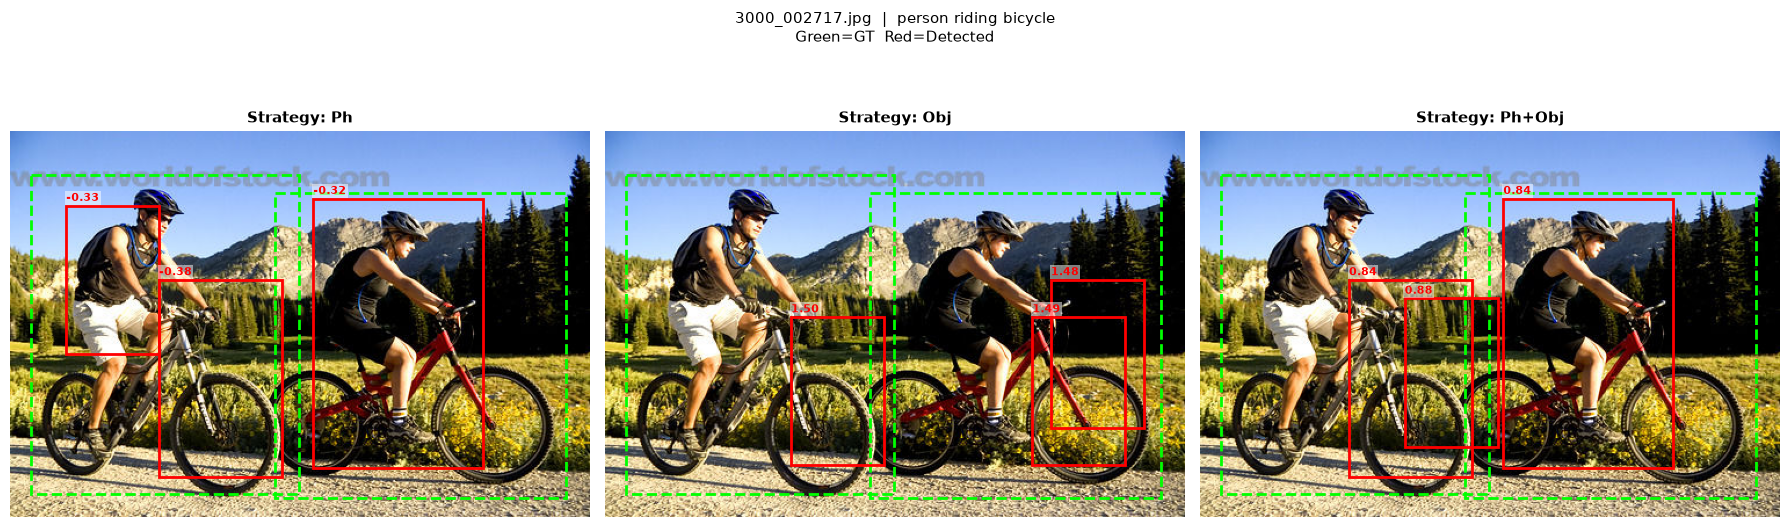

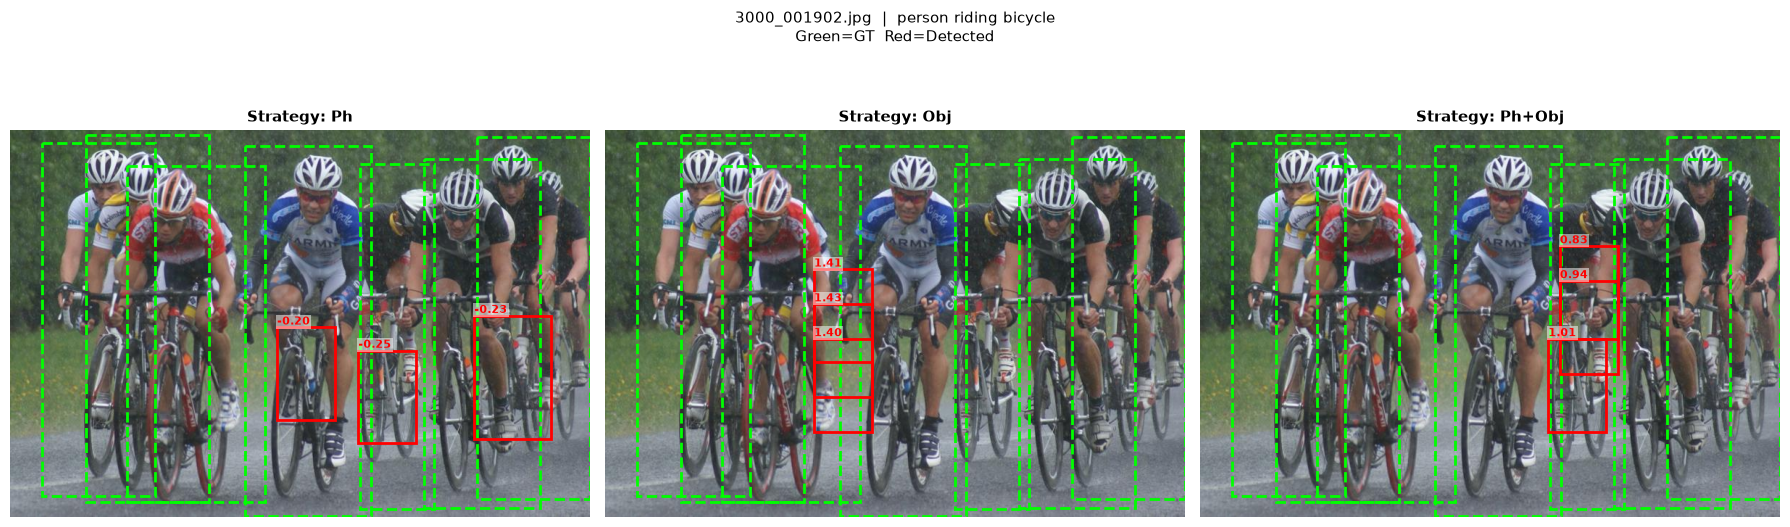

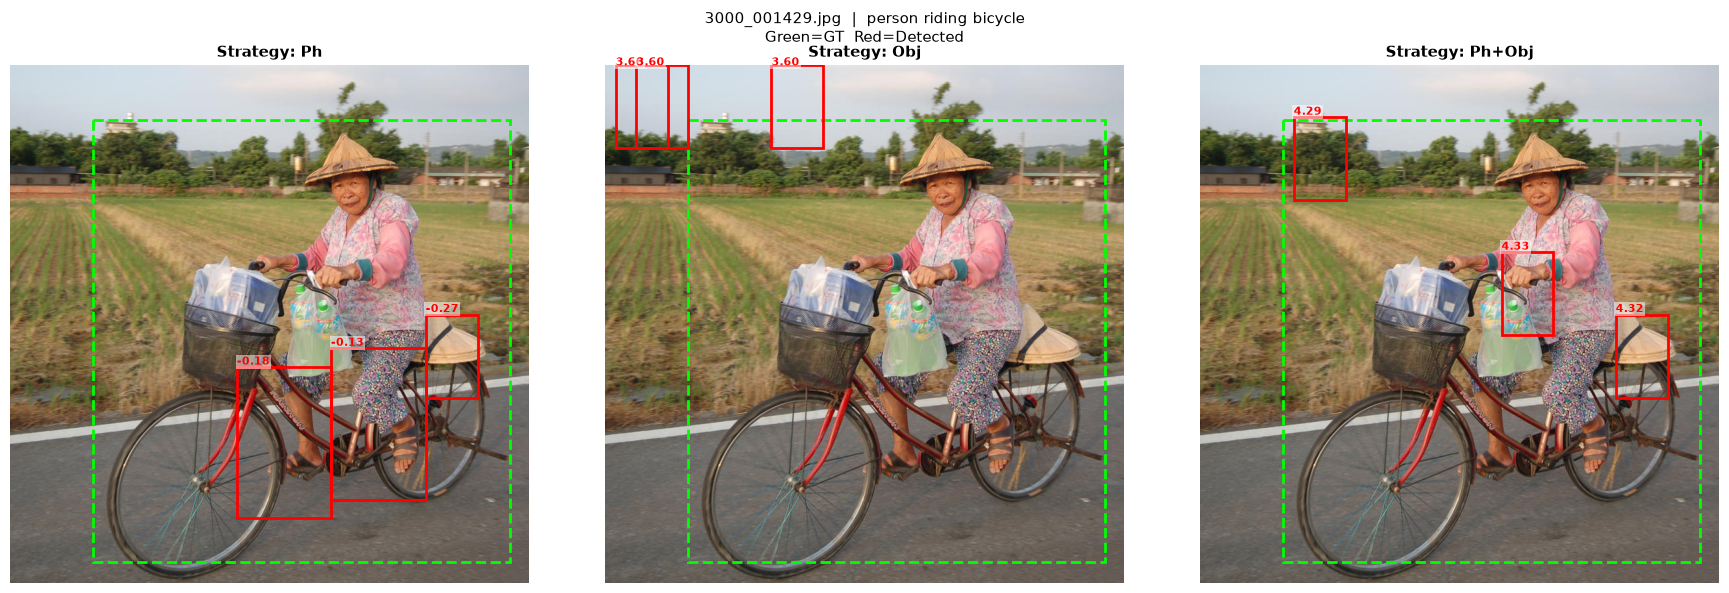

In [20]:
def show_detections(ann, results, phrase):
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, ann['filename'])), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    gt_boxes = [o['bbox'] for o in ann['objects'] if o['name'] == phrase]
    for ax, strategy in zip(axes, ['Ph', 'Obj', 'Ph+Obj']):
        ax.imshow(img)
        for gt in gt_boxes:
            x1,y1,x2,y2 = gt
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                         lw=2, edgecolor='lime', facecolor='none', linestyle='--'))
        for det_box, sc in results[strategy][:3]:
            x1,y1,x2,y2 = det_box
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                         lw=2, edgecolor='red', facecolor='none'))
            ax.text(x1, max(y1-4,0), f'{sc:.2f}', color='red', fontsize=8,
                    fontweight='bold', bbox=dict(facecolor='white',alpha=0.5,pad=1,edgecolor='none'))
        ax.set_title(f'Strategy: {strategy}', fontsize=11, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f"{ann['filename']}  |  {phrase.replace('_',' ')}\nGreen=GT  Red=Detected", fontsize=11)
    plt.tight_layout(); plt.show()


for ann in ph_test_anns[:3]:
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, ann['filename'])), cv2.COLOR_BGR2RGB)
    res = infer_3_strategies(img, ph_clf, WIN[TARGET], ctx_clf_obj, ctx_clf_phobj)
    show_detections(ann, res, TARGET)

## 10. Evaluation — Average Precision (AP)
Standard VOC IoU ≥ 0.5 criterion. Compare the 3 strategies like Table 1 in the paper.

In [21]:
def iou(a, b):
    x1 = max(a[0],b[0]); y1 = max(a[1],b[1])
    x2 = min(a[2],b[2]); y2 = min(a[3],b[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    ua    = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / (ua + 1e-8)


def voc_ap(dets, gt_boxes_list, iou_thr=0.5):
    """
    dets           : list of (img_idx, bbox, score) over ALL test images (flattened)
    gt_boxes_list  : list of lists — gt_boxes_list[i] = gt boxes for image i
    """
    # tuple is (img_idx, bbox, score) — sort by score descending
    dets = sorted(dets, key=lambda x: -x[2])
    n_gt = sum(len(g) for g in gt_boxes_list)
    if n_gt == 0: return 0.0

    matched = [set() for _ in gt_boxes_list]
    tp = np.zeros(len(dets))
    fp = np.zeros(len(dets))

    for k, (img_idx, bbox, score) in enumerate(dets):
        gts = gt_boxes_list[img_idx]
        best = -1; best_iou = 0
        for j, gt in enumerate(gts):
            v = iou(bbox, gt)
            if v > best_iou:
                best_iou = v; best = j
        if best_iou >= iou_thr and best not in matched[img_idx]:
            tp[k] = 1; matched[img_idx].add(best)
        else:
            fp[k] = 1

    cum_tp = np.cumsum(tp); cum_fp = np.cumsum(fp)
    prec   = cum_tp / (cum_tp + cum_fp + 1e-10)
    rec    = cum_tp / (n_gt + 1e-10)
    ap     = float(np.trapezoid(prec, rec))
    return ap

print('AP functions ready')

AP functions ready


In [22]:
strategy_dets = {'Ph': [], 'Obj': [], 'Ph+Obj': []}
gt_per_img    = []

for img_idx, ann in enumerate(ph_test_anns):
    img = cv2.imread(os.path.join(IMG_DIR, ann['filename']))
    if img is None: gt_per_img.append([]); continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt_per_img.append([o['bbox'] for o in ann['objects'] if o['name'] == TARGET])
    res = infer_3_strategies(img, ph_clf, WIN[TARGET], ctx_clf_obj, ctx_clf_phobj)
    for s in strategy_dets:
        for bbox, score in res[s]:
            strategy_dets[s].append((img_idx, bbox, score))

print(f'Test images: {len(ph_test_anns)}')
for s, dets in strategy_dets.items():
    print(f'  {s}: {len(dets)} detections')

Test images: 24
  Ph: 240 detections
  Obj: 240 detections
  Ph+Obj: 240 detections



=== AP Results (IoU ≥ 0.5) — mirrors paper Table 1 ===
Strategy          AP
----------------------
Ph            0.0870
Obj           0.0006
Ph+Obj        0.0149


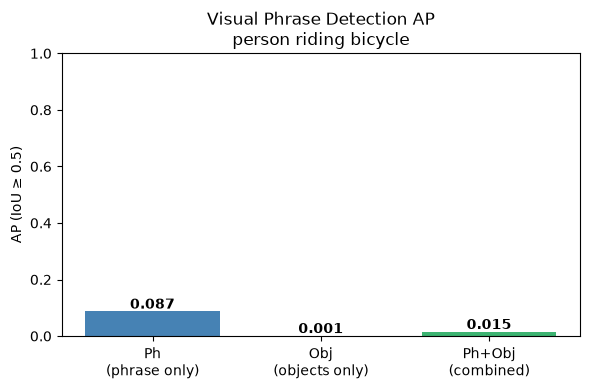

In [23]:
print('\n=== AP Results (IoU ≥ 0.5) — mirrors paper Table 1 ===')
print(f'{"Strategy":<12}  {"AP":>6}')
print('-'*22)
aps = {}
for s in ['Ph', 'Obj', 'Ph+Obj']:
    ap = voc_ap(strategy_dets[s], gt_per_img)
    aps[s] = ap
    print(f'{s:<12}  {ap:>6.4f}')

# bar chart
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Ph\n(phrase only)', 'Obj\n(objects only)', 'Ph+Obj\n(combined)'],
       [aps['Ph'], aps['Obj'], aps['Ph+Obj']],
       color=['steelblue', 'coral', 'mediumseagreen'])
ax.set_ylabel('AP (IoU ≥ 0.5)')
ax.set_title(f'Visual Phrase Detection AP\n{TARGET.replace("_"," ")}')
ax.set_ylim(0, 1)
for i, (s, v) in enumerate(aps.items()):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Visualize Learned Model Weights
Like voc-release5 `visualizemodel.m` — shows which spatial regions the phrase DPM fires on.

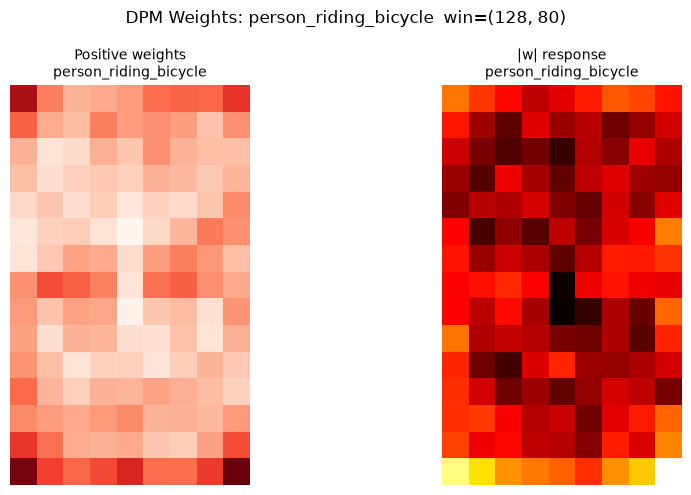

NameError: name 'obj_clfs' is not defined

In [24]:
def visualize_dpm_weights(clf, win, label=''):
    """Show SVM weight magnitude spatially — mimics visualizemodel.m."""
    w = clf.coef_[0]
    n_ch = win[0] // HOG_PIX[0]; n_cw = win[1] // HOG_PIX[1]
    n_bh = n_ch - HOG_BLK[0] + 1; n_bw = n_cw - HOG_BLK[1] + 1
    feat_per_block = HOG_ORI * HOG_BLK[0] * HOG_BLK[1]

    if len(w) != n_bh * n_bw * feat_per_block:
        plt.figure(figsize=(12,2)); plt.plot(np.abs(w)); plt.title(f'|w| — {label}'); plt.show()
        return

    W_map   = w.reshape(n_bh, n_bw, feat_per_block)
    mag     = np.abs(W_map).mean(axis=2)
    pos_map = np.maximum(W_map, 0).mean(axis=2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(pos_map, cmap='Reds'); axes[0].set_title(f'Positive weights\n{label}', fontsize=10); axes[0].axis('off')
    axes[1].imshow(mag, cmap='hot');      axes[1].set_title(f'|w| response\n{label}', fontsize=10); axes[1].axis('off')
    plt.suptitle(f'DPM Weights: {label}  win={win}', fontsize=12)
    plt.tight_layout(); plt.show()


if ph_clf is not None:
    visualize_dpm_weights(ph_clf, WIN[TARGET], label=TARGET)
for cls, clf in obj_clfs.items():
    visualize_dpm_weights(clf, WIN[cls], label=cls)

## 12. Batch: Train & Evaluate All Phrases
Runs the full pipeline for each visual phrase and summarizes AP across all three strategies.

In [ ]:
# pick phrases with enough images for training
DEMO_PHRASES = [ph for ph in PHRASES if len(phrase_to_anns[ph]) >= 50]
print(f'Phrases with >= 50 images: {DEMO_PHRASES}')

In [ ]:
all_phrase_ap = {}

for phrase in DEMO_PHRASES:
    print(f'\n{"="*60}')
    print(f'Processing: {phrase}')

    p_clf, _, p_test = train_dpm(phrase, all_anns, scales=PH_SCALES,
                                  n_neg_init=300, n_hn=300, hn_rounds=2)
    if p_clf is None:
        print('  skipping — no model'); continue

    parts = phrase.split('_')
    subj, obj = parts[0], parts[-1]
    o_clfs = {}
    for cls in set([subj, obj]):
        if cls in OBJ_CLS:
            clf_o, _, _ = train_dpm(cls, all_anns, scales=OBJ_SCALES,
                                     n_neg_init=200, n_hn=200, hn_rounds=1)
            if clf_o is not None: o_clfs[cls] = clf_o
    o_wins = {c: WIN[c] for c in o_clfs}

    s_dets = {'Ph': [], 'Obj': [], 'Ph+Obj': []}
    gt_per = []
    for img_idx, ann in enumerate(p_test):
        img = cv2.imread(os.path.join(IMG_DIR, ann['filename']))
        if img is None: gt_per.append([]); continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gt_per.append([o['bbox'] for o in ann['objects'] if o['name'] == phrase])
        res = infer_3_strategies(img, p_clf, WIN[phrase], o_clfs, o_wins)
        for s in s_dets:
            for bbox, sc in res[s]:
                s_dets[s].append((img_idx, bbox, sc))

    phrase_ap = {s: voc_ap(s_dets[s], gt_per) for s in s_dets}
    all_phrase_ap[phrase] = phrase_ap
    print(f'  AP  Ph={phrase_ap["Ph"]:.3f}  Obj={phrase_ap["Obj"]:.3f}  Ph+Obj={phrase_ap["Ph+Obj"]:.3f}')

print('\nAll done!')

In [ ]:
# summary table
if all_phrase_ap:
    print(f'\n{"Phrase":<35} {"Ph":>6} {"Obj":>6} {"Ph+Obj":>8}')
    print('-'*60)
    for ph, aps in sorted(all_phrase_ap.items()):
        print(f'{ph:<35} {aps["Ph"]:>6.3f} {aps["Obj"]:>6.3f} {aps["Ph+Obj"]:>8.3f}')
    
    # mean AP
    for s in ['Ph', 'Obj', 'Ph+Obj']:
        vals = [v[s] for v in all_phrase_ap.values()]
        print(f'  mean {s}: {np.mean(vals):.3f}')

In [ ]:
# grouped bar chart — like paper Figure 4
if all_phrase_ap:
    phrases  = list(all_phrase_ap.keys())
    ph_ap    = [all_phrase_ap[p]['Ph']     for p in phrases]
    obj_ap   = [all_phrase_ap[p]['Obj']    for p in phrases]
    comb_ap  = [all_phrase_ap[p]['Ph+Obj'] for p in phrases]
    
    x = np.arange(len(phrases))
    w = 0.25
    
    fig, ax = plt.subplots(figsize=(max(12, len(phrases)*2), 5))
    ax.bar(x - w,   ph_ap,   width=w, label='Ph',     color='steelblue')
    ax.bar(x,       obj_ap,  width=w, label='Obj',    color='coral')
    ax.bar(x + w,   comb_ap, width=w, label='Ph+Obj', color='mediumseagreen')
    
    ax.set_xticks(x)
    ax.set_xticklabels([p.replace('_','\n') for p in phrases], fontsize=7)
    ax.set_ylabel('AP (IoU ≥ 0.5)')
    ax.set_title('Visual Phrase Detection — AP per Phrase (paper Table 1 style)')
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout(); plt.show()

## 13. Save / Load Models

In [ ]:
SAVE_DIR  = r'G:\Engineering\GP\Expirements\VRD'
save_path = os.path.join(SAVE_DIR, 'vrd_models.pkl')

payload = {
    'ph_clf':        ph_clf,
    'obj_clfs':      obj_clfs,
    'target':        TARGET,
    'windows':       WIN,            # per-label (H,W) aspect-aware windows
    'all_phrase_ap': all_phrase_ap,
}
with open(save_path, 'wb') as f:
    pickle.dump(payload, f)
print(f'saved → {save_path}')

# reload:
# with open(save_path, 'rb') as f: m = pickle.load(f)
# ph_clf = m['ph_clf']; obj_clfs = m['obj_clfs']; WIN.update(m['windows'])

---
## Summary

| Component | Paper | This notebook |
|---|---|---|
| Feature | HOG (voc-release5, 8×8 cells, 9 bins) | `skimage.hog` same params |
| Model | DPM (mixture star model) | LinearSVC (equivalent linear detector) |
| Training | latent SVM + hard negative mining | LinearSVC + manual HN mining |
| Obj models | Pre-trained VOC DPMs | HOG+SVM trained on individual object anns |
| Inference | 3 strategies: Ph / Obj / Ph+Obj | same |
| Evaluation | VOC AP IoU≥0.5 | same |

**Paper key finding:** Ph+Obj consistently outperforms either alone — the holistic phrase appearance (Ph) captures spatial co-occurrence, while the object scores (Obj) add class-discriminative power.
